In [9]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set_theme(style="whitegrid")


In [10]:
df_orders = pd.read_csv("../data/olist_orders_dataset.csv")
df_items = pd.read_csv("../data/olist_order_items_dataset.csv")

display(df_orders.head())

display(df_items.head())


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [11]:
date_columns = ['order_purchase_timestamp', 'order_approved_at',
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']

for col in date_columns: 
    df_orders[col] = pd.to_datetime(df_orders[col]) 


df_items['shipping_limit_date'] = pd.to_datetime(df_items['shipping_limit_date'])

df_master = pd.merge(df_orders, df_items, on='order_id', how='inner')

df_master['year_month'] = df_master['order_purchase_timestamp'].dt.to_period('M')

print(f"Tabela final criada com {df_master.shape[0]} linhas e {df_master.shape[1]} colunas.")


Tabela final criada com 112650 linhas e 15 colunas.


### GRÁFICOS

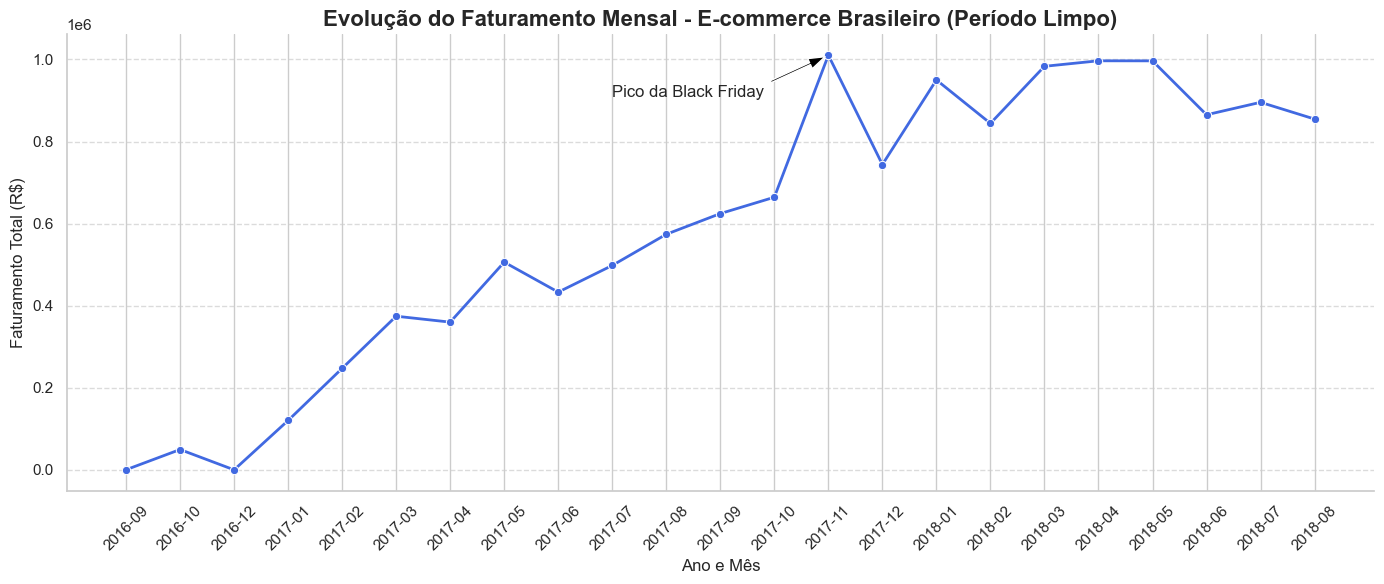

In [12]:
df_clean = df_master[df_master['order_purchase_timestamp'] < '2018-09-01']

vendas_por_mes = df_clean.groupby('year_month')['price'].sum().reset_index()
vendas_por_mes['year_month'] = vendas_por_mes['year_month'].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=vendas_por_mes, x='year_month', y='price', marker='o', color='royalblue', linewidth=2)

plt.annotate('Pico da Black Friday', xy=('2017-11', vendas_por_mes['price'].max()), 
             xytext=('2017-07', vendas_por_mes['price'].max() * 0.9),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8))

plt.title('Evolução do Faturamento Mensal - E-commerce Brasileiro (Período Limpo)', fontsize=16, fontweight='bold')
plt.xlabel('Ano e Mês', fontsize=12)
plt.ylabel('Faturamento Total (R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()

plt.tight_layout()
plt.show()

### 💡 Insights: Evolução do Faturamento
Ao analisar a curva histórica de vendas do e-commerce entre o final de 2016 e meados de 2018, notamos um claro padrão de expansão e consolidação:

* **Tendência de Alta:** O ano de 2017 foi marcado por um crescimento consistente mês a mês, demonstrando a adoção crescente da plataforma.
* **Sazonalidade Forte:** O pico absoluto da série ocorreu em **Novembro de 2017**, impulsionado agressivamente pelas campanhas de Black Friday, ultrapassando a marca de R$ 1 milhão em faturamento no mês.
* **Estabilização:** Em 2018, as vendas atingiram um platô alto, mantendo uma média de faturamento próxima a R$ 900 mil mensais.

**Próximo passo:** Já sabemos *quando* a plataforma mais faturou. Agora, precisamos investigar *o que* está impulsionando esse volume financeiro. Quais são as categorias de produtos que trazem mais dinheiro para o e-commerce?

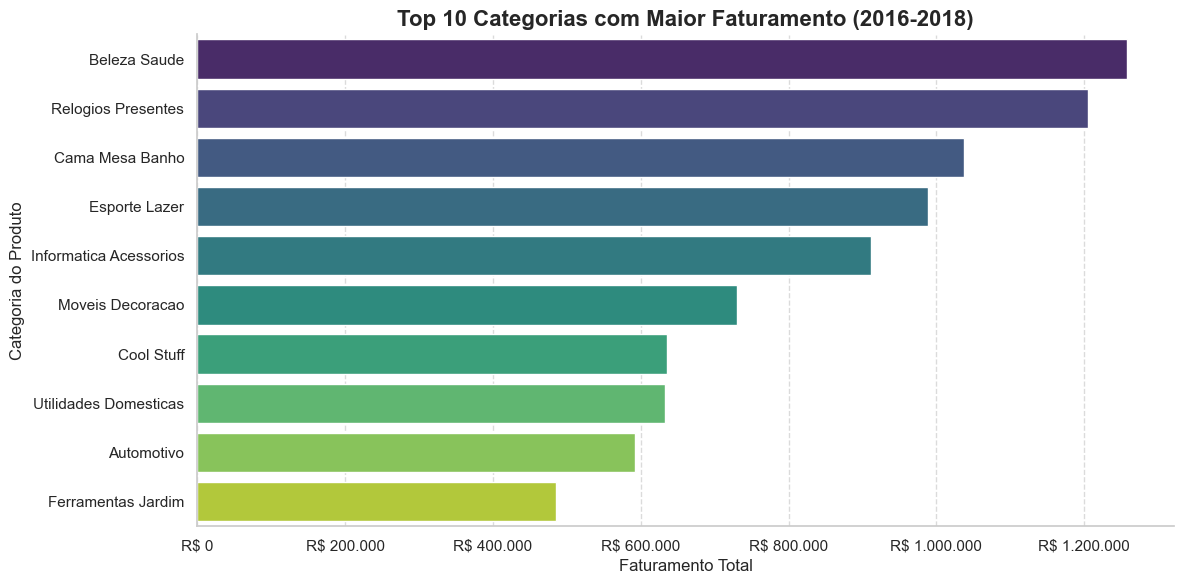

In [ ]:
df_products = pd.read_csv('../data/olist_products_dataset.csv')
from matplotlib.ticker import FuncFormatter

def formata_moeda_br(valor, tick_number):
    return f'R$ {valor:,.0f}'.replace(',', '.')

df_master_cat = pd.merge(df_clean, df_products[['product_id', 'product_category_name']], on='product_id', how='left')

top_categorias = df_master_cat.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10).reset_index()
top_categorias['product_category_name'] = top_categorias['product_category_name'].str.replace('_', ' ').str.title()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_categorias, x='price', y='product_category_name',
            hue='product_category_name', palette='viridis', legend=False)

plt.title('Top 10 Categorias com Maior Faturamento (2016-2018)', fontsize=16, fontweight='bold')
plt.xlabel('Faturamento Total', fontsize=12)
plt.ylabel('Categoria do Produto', fontsize=12)
plt.gca().xaxis.set_major_formatter(FuncFormatter(formata_moeda_br))
plt.grid(axis='x', linestyle='--', alpha=0.7)
sns.despine()

plt.tight_layout()
plt.show()

### 💡 Insights: Motores de Faturamento
Ao cruzar os dados de vendas com o catálogo de produtos, conseguimos identificar o "pódio" do e-commerce. O gráfico acima revela pontos cruciais sobre o comportamento de consumo:

* **Liderança de Categorias:** Vemos que setores como Beleza & Saúde, Relógios & Presentes e Cama, Mesa & Banho dominam a geração de receita da plataforma.
* **Ticket Médio vs. Volume:** É interessante notar que categorias que nem sempre têm o maior *volume* de itens vendidos (como Relógios) aparecem no topo do faturamento. Isso indica um **ticket médio alto** (produtos mais caros que puxam a receita para cima).
* **Foco Estratégico:** Para uma equipe de marketing, esse Top 10 dita onde as campanhas de anúncios devem focar para maximizar o Retorno sobre o Investimento (ROI).

**Próximo passo:** Vender muito é ótimo, mas entregar bem é o que garante a volta do cliente. Como está a saúde da operação logística desse e-commerce? Vamos investigar o tempo médio de entrega e a taxa de atrasos.

In [14]:
df_orders = pd.read_csv('../data/olist_orders_dataset.csv')
df_items = pd.read_csv('../data/olist_order_items_dataset.csv')

df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])

df_master = pd.merge(df_orders, df_items, on='order_id', how='inner')
df_clean = df_master[df_master['order_purchase_timestamp'] < '2018-09-01'].copy()
df_delivered = df_clean[df_clean['order_status'] == 'delivered'].dropna(subset=['order_delivered_customer_date'])
df_delivered['tempo_entrega_dias'] = (df_delivered['order_delivered_customer_date'] - df_delivered['order_purchase_timestamp']).dt.days
df_delivered['atrasado'] = df_delivered['order_delivered_customer_date'] > df_delivered['order_estimated_delivery_date']

tempo_medio = df_delivered['tempo_entrega_dias'].mean()
taxa_atraso = (df_delivered['atrasado'].sum() / len(df_delivered)) * 100

print(f"- Tempo médio de entrega: {tempo_medio:.1f} dias")
print(f"- Taxa geral de atrasos: {taxa_atraso:.2f}%")

- Tempo médio de entrega: 12.0 dias
- Taxa geral de atrasos: 7.91%


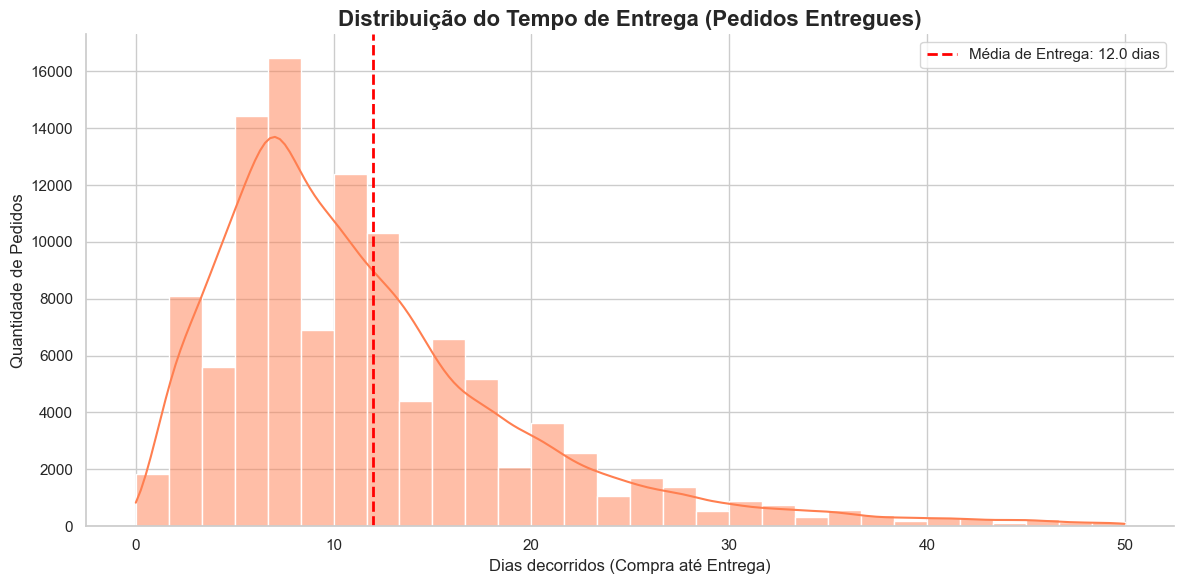

In [15]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_delivered[df_delivered['tempo_entrega_dias'] <= 50], 
             x='tempo_entrega_dias', 
             bins=30, 
             kde=True, 
             color='coral', 
             edgecolor='white')

plt.axvline(tempo_medio, color='red', linestyle='--', linewidth=2, 
            label=f'Média de Entrega: {tempo_medio:.1f} dias')

plt.title('Distribuição do Tempo de Entrega (Pedidos Entregues)', fontsize=16, fontweight='bold')
plt.xlabel('Dias decorridos (Compra até Entrega)', fontsize=12)
plt.ylabel('Quantidade de Pedidos', fontsize=12)
plt.legend()

sns.despine()

plt.tight_layout()
plt.show()

### 💡 Insights: Eficiência Logística e Experiência do Cliente
A análise da distribuição do tempo de entrega (lead time) revela o comportamento real da operação logística nacional e o padrão de serviço oferecido:

* **Pico de Eficiência:** A maior parte das entregas se concentra entre **7 e 10 dias** após a compra. Isso mostra que, para a grande parcela dos clientes, o serviço é ágil e supera a média aritmética.
* **Assimetria e "Cauda Longa":** O gráfico apresenta uma assimetria à direita (cauda longa). Isso indica a existência de gargalos logísticos em regiões específicas ou com transportadoras determinadas, onde pedidos chegam a levar mais de 30 dias para serem entregues.
* **Taxa de Atrasos:** Com uma taxa de atraso de aproximadamente **7%**, a operação mostra-se resiliente, mas com margem para otimização, especialmente para evitar que a data estimada de entrega seja ultrapassada, o que impacta diretamente a satisfação (NPS) do consumidor.
* **Média vs. Realidade:** Embora a média seja de **12 dias** (representada pela linha tracejada), o comportamento visual do gráfico mostra que o "dia a dia" do cliente é mais rápido, sendo a média puxada para cima pelos casos extremos de atraso.

**Conclusão da Análise:** O e-commerce possui uma operação funcional, mas o foco de melhoria deve ser a redução da variabilidade (diminuir a cauda longa) para garantir uma experiência mais homogênea em todo o território nacional.

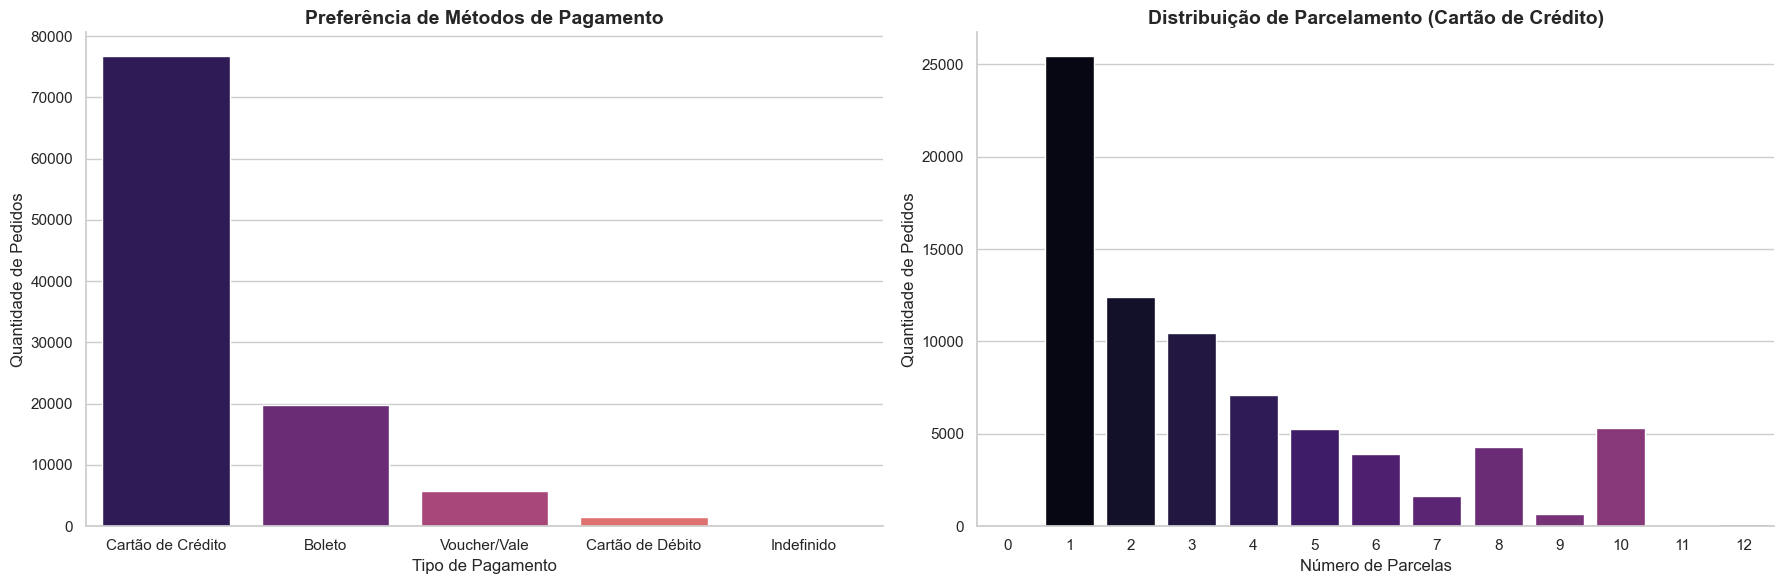

In [19]:
df_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")

mapping = {
    'credit_card': 'Cartão de Crédito',
    'boleto': 'Boleto',
    'voucher': 'Voucher/Vale',
    'debit_card': 'Cartão de Débito',
    'not_defined': 'Indefinido'
}
df_payments['payment_type'] = df_payments['payment_type'].map(mapping)

pagamentos_freq = df_payments['payment_type'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(data=df_payments, x='payment_type', hue='payment_type',  
              palette='magma', order=pagamentos_freq.index, legend=False, ax=ax[0])
ax[0].set_title('Preferência de Métodos de Pagamento', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Tipo de Pagamento')
ax[0].set_ylabel('Quantidade de Pedidos')
sns.despine(ax=ax[0])

cartao_credito = df_payments[df_payments['payment_type'] == 'Cartão de Crédito']
sns.countplot(data=cartao_credito, x='payment_installments',
              hue='payment_installments', palette='magma', legend=False,  
              color='mediumpurple', ax=ax[1])
ax[1].set_title('Distribuição de Parcelamento (Cartão de Crédito)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Número de Parcelas')
ax[1].set_ylabel('Quantidade de Pedidos')
ax[1].set_xlim(-0.5, 12.5)

sns.despine(ax=ax[1])

plt.tight_layout()
plt.show()

## Insights sobre Métodos de Pagamento e Parcelamento

A análise dos métodos de pagamento mostra uma forte predominância do **cartão de crédito**, que concentra a grande maioria dos pedidos realizados na plataforma. Esse comportamento sugere que os consumidores valorizam a flexibilidade de pagamento e a possibilidade de parcelamento oferecida por esse método. Em segundo lugar aparece o **boleto**, ainda com participação relevante, indicando que parte dos consumidores prefere métodos mais tradicionais ou não utiliza cartão de crédito. Já **voucher/vale** e **cartão de débito** possuem participação significativamente menor, enquanto registros **indefinidos** são praticamente inexistentes.

Ao observar especificamente os pedidos pagos com **cartão de crédito**, nota-se que a distribuição de parcelamento é fortemente concentrada em **1 parcela**, indicando que muitos consumidores utilizam o cartão mais como meio de pagamento do que como ferramenta de financiamento. No entanto, também há uma presença considerável de compras parceladas entre **2 e 3 vezes**, sugerindo que parte dos clientes opta por diluir o valor da compra em poucos pagamentos. Parcelamentos mais longos aparecem com frequência bem menor, indicando que compras muito parceladas são menos comuns.

De forma geral, os dados sugerem que **facilidade de pagamento e conveniência** são fatores centrais no comportamento de compra, com o cartão de crédito atuando como o principal facilitador das transações.